ThinCurr Python Example: Compute eigenstates of  coupled wall, plasma, and coil model
==========
In this example we demonstrate how to compute eigenvalues and eigenvectors for the coupled wall, plasma, and coil RWM model.

**Note:** Running this example requires the [h5py](https://www.h5py.org/) and [pyvista](https://pyvista.org/) python packages, which are installable using `pip` or other standard methods.

In [1]:
import struct
import sys
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"



## Load ThinCurr library

To load the ThinCurr python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` for binaries on macOS).

In [ ]:
thincurr_python_path = os.getenv('OFT_ROOTPATH')
if thincurr_python_path is not None:
    sys.path.append(os.path.join(thincurr_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.ThinCurr import ThinCurr
from OpenFUSIONToolkit.ThinCurr.meshing import build_torus_bnorm_grid, ThinCurr_periodic_toroid
from OpenFUSIONToolkit.ThinCurr.sensor import Mirnov, save_sensors
from OpenFUSIONToolkit.ThinCurr.boozerRWM import RWMmodel 
from OpenFUSIONToolkit.io import histfile

try:
    import pyvista
    pyvista.set_jupyter_backend('static') # Comment to enable interactive PyVista plots
    have_pyvista = True
except ImportError:
    have_pyvista = False

## Compute eigenvalues

### Setup ThinCurr model
We now create a \ref OpenFUSIONToolkit.OFT_env "OFT_env" instance for execution using two threads and a \ref OpenFUSIONToolkit.ThinCurr.ThinCurr "ThinCurr" instance that utilizes that execution environment.


In [3]:
myOFT = OFT_env(nthreads=2)


#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    main
Revision id:           1a4bc3c
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Integer Precisions    =    4   8
Float Precisions      =    4   8  10
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------



Once created, we setup the wall (torus) model from an existing HDF5 and XML mesh definition using \ref OpenFUSIONToolkit.ThinCurr.ThinCurr.setup_model "setup_model()".

Finally, we initialize I/O for this model using \ref OpenFUSIONToolkit.ThinCurr.ThinCurr.setup_io "setup_io()" to enable output of plotting files for 3D visualization in [VisIt](https://visit-dav.github.io/visit-website/index.html), [Paraview](https://www.paraview.org/), or using [pyvista](https://pyvista.org/).

In [4]:
tw_torus = ThinCurr(myOFT)
tw_torus.setup_model(mesh_file='thincurr_ex-torus.h5',xml_filename='coils_cyl.xml')
tw_torus.setup_io()



Creating thin-wall model
  Loading V(t) driver coils
    Masked      4 coils from sensors
  No I(t) driver coils found
  Building holes

  Loading region surface resistivity:
     1  4.0000E-03

  Setup complete:
    # of points    =         2394
    # of edges     =         7182
    # of cells     =         4788
    # of holes     =            2
    # of closures  =            0
    # of Vcoils    =            4
    # of Icoils    =            0


### Setup plasma mode driver model
We now create a second \ref OpenFUSIONToolkit.ThinCurr.ThinCurr "ThinCurr" instance for the plasma mode utilizes the same execution environment as above. For this case we also load the plasma mode current patterns created in \ref doc_tCurr_torus_mode.

In [5]:
tw_mode = ThinCurr(myOFT)
tw_mode.setup_model(mesh_file='thincurr_mode.h5', xml_filename='coils_cyl.xml')

with h5py.File('thincurr_mode.h5', 'r+') as h5_file:
    mode_drive = np.asarray(h5_file['thincurr/driver'])


Creating thin-wall model
  Loading V(t) driver coils
    Masked      4 coils from sensors
  No I(t) driver coils found
  Building holes

  Loading region surface resistivity:
     1  4.0000E-03

  Setup complete:
    # of points    =         6320
    # of edges     =        18960
    # of cells     =        12640
    # of holes     =            3
    # of closures  =            2
    # of Vcoils    =            4
    # of Icoils    =            0


## Calculate constant matrices to establish RWM model
Calculate Uncoupled inductance and resistance matrices for the plasma, wall, and coils. Rmat (called R) is automatically calculated when the rwm model is created. 

In [6]:
rwm_model = RWMmodel(tw_torus,tw_mode,mode_drive)

Building coil<->element inductance matrices


    516605 intersecting elements for coil      1
   1022120 intersecting elements for coil      2
   1021938 intersecting elements for coil      3
   1022120 intersecting elements for coil      4
  Time =  0s          
Building coil<->coil inductance matrix
  Time =  0s          
  Vcoil    1: L [H] =   2.9002E-07
  Vcoil    2: L [H] =   1.6884E-07
  Vcoil    3: L [H] =   1.6884E-07
  Vcoil    4: L [H] =   1.6884E-07
Building element<->element self inductance matrix
  Time =  1m 12s      
Building coil<->element inductance matrices


    198550 intersecting elements for coil      1
    378155 intersecting elements for coil      2
    393311 intersecting elements for coil      3
    383329 intersecting elements for coil      4
  Time =  0s          
Building coil<->coil inductance matrix
  Time =  0s          
  Vcoil    1: L [H] =   2.9002E-07
  Vcoil    2: L [H] =   1.6884E-07
  Vcoil    3: L [H] =   1.6884E-07
  Vcoil    4: L [H] =   1.6884E-07
Building element<->element self inductance matrix
  Time = 15s          
Building element<->element mutual inductance matrix
  Time = 57s          
Building resistivity matrix
  Vcoil    1: R [Ohm] =   1.3488E-07
  Vcoil    2: R [Ohm] =   1.3488E-07
  Vcoil    3: R [Ohm] =   1.3488E-07
  Vcoil    4: R [Ohm] =   1.3488E-07
Building resistivity matrix
  Vcoil    1: R [Ohm] =   1.3488E-07
  Vcoil    2: R [Ohm] =   1.3488E-07
  Vcoil    3: R [Ohm] =   1.3488E-07
  Vcoil    4: R [Ohm] =   1.3488E-07


## Choose s and α Boozer stability and troque parameters and cacluclate inductance 

These values are the primary user inputs into a given RWM model. The s-paramter determines the open-loop stability of the plasma, where a negative s is stable and a positive s is unstable, unless a non-zero α value is provided. The torque parameter α representats a stabilizing plasma rotation. 

Once the s and α parameters have been chosen, the effective coupled inductance matrix can be calculated. 


In [7]:
s = -0.3
a = 0.5
rwm_model.compute_L_ef(s,a)

## Calculate eigenvalues and eigenvectors of $$-L^{-1}*R$$

Number of eigenvalues calculated can be sepecified, automatically set to 20. 

In [8]:
eig_vals, eig_vecs = rwm_model.eigenvalues()

## Plot eigenvalues 
Plot real and imaginary components, where the real part represents the growth or decay rate of the mode, and the imaginary part represents the frequency of roation. 

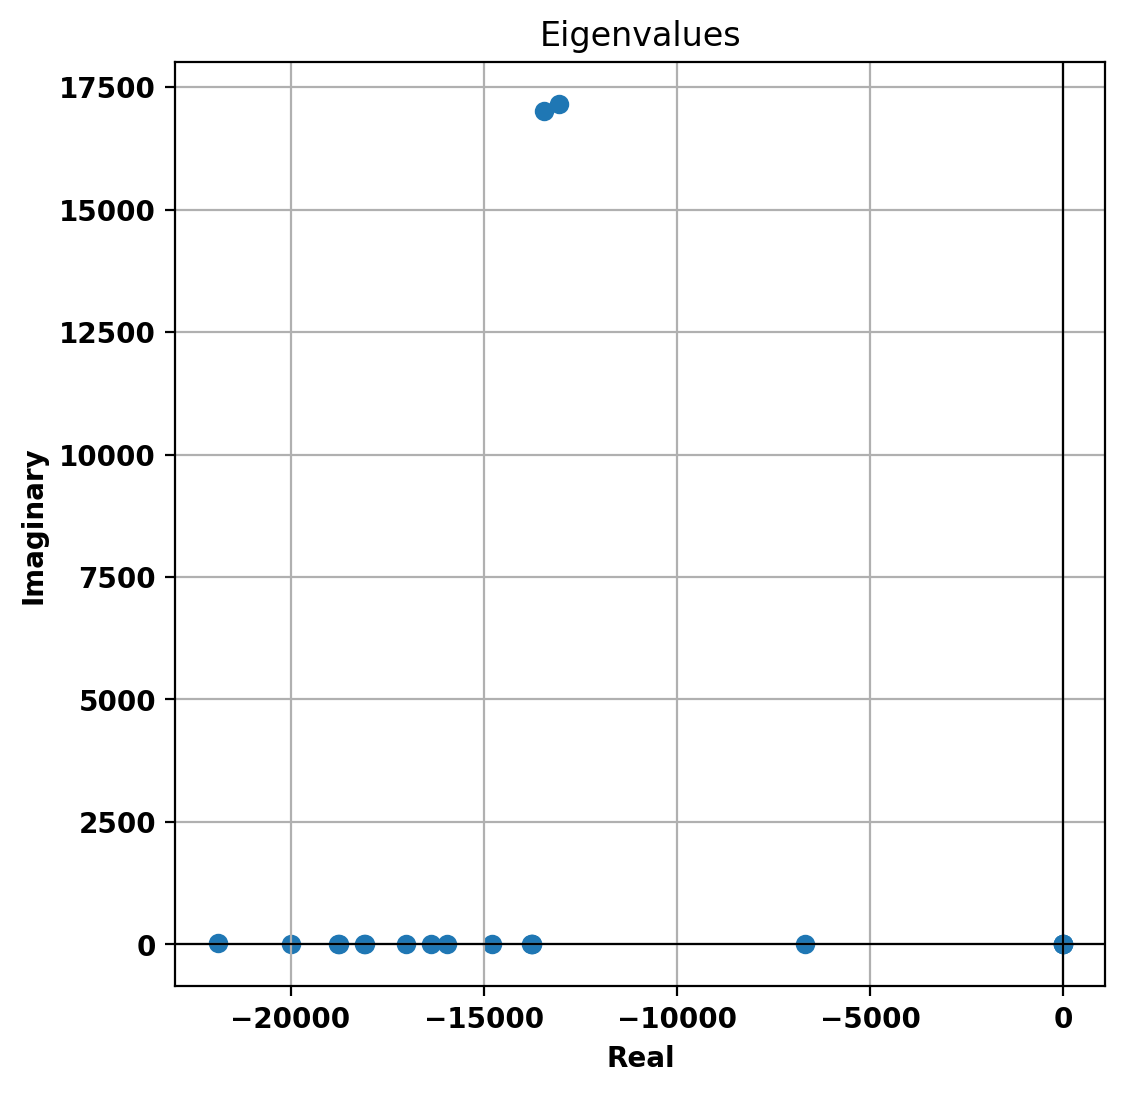

In [9]:
rwm_model.plot()

## Perform a parameter sweep 

View the stability of the mode for a range of s and α values. 

In [10]:
a_vals = np.linspace(0.1,2.0,5)
s_vals = np.linspace(-0.5,2.0,5)

eig = np.zeros((len(s_vals), len(a_vals)), dtype=complex) 
cur = np.zeros((len(s_vals), len(a_vals)), dtype=complex) 


for i, s in enumerate(s_vals):
    for j, a in enumerate(a_vals):
        rwm_model.compute_L_ef(s, a)
        eig_vals, eig_vecs = rwm_model.eigenvalues(20)
        eig_vals = sorted(eig_vals, key=lambda x: x.imag, reverse=False)
        eig_vals = eig_vals[19]
        eig[i,j] = eig_vals
            

Plot the real part of the eigenvalue with the largest imaginary part, where negative values are stable. 

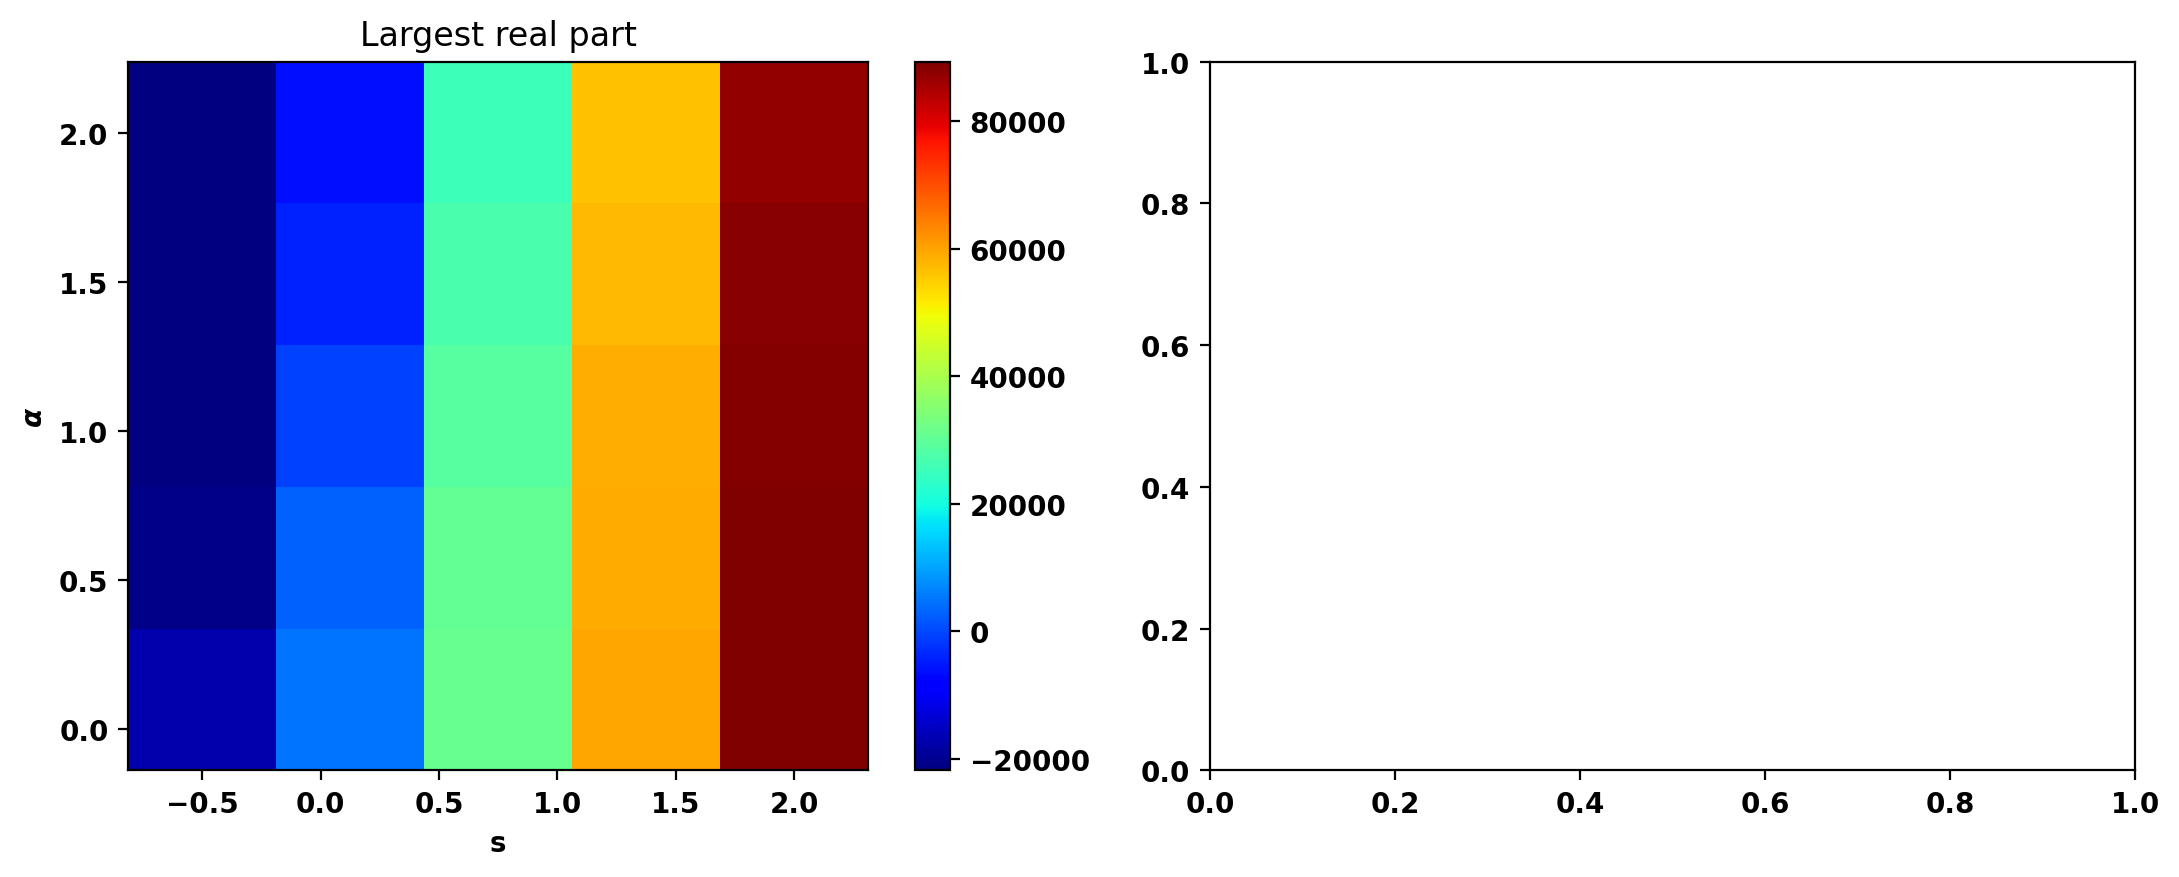

In [11]:
plt.close('all')

S, A = np.meshgrid(s_vals, a_vals, indexing='ij')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

plt.rc('axes', labelsize=16)
plt.rc('figure', titlesize = 20)
pcm1 = ax1.pcolormesh(S, A, eig.real, shading='auto', cmap='jet')
ax1.set_xlabel('s')
ax1.set_ylabel(r'$\alpha$')
ax1.set_title(f'Largest real part')
fig.colorbar(pcm1, ax=ax1)

#%config InlineBackend.figure_format = 'svg'

plt.tight_layout()
plt.show()
